In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

In [161]:
df = pd.read_csv('concrete_data.csv')

In [162]:
df.head(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [163]:
df.shape

(1030, 9)

In [164]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [165]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [166]:
x = df.iloc[:,0:8]
y = df.iloc[:,-1]

In [167]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

In [168]:
LR = LinearRegression()

In [169]:
LR.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [170]:
y_pred = LR.predict(x_test)

r2_score(y_test,y_pred)

0.6275531792314848

In [171]:
lr = LinearRegression()
cross_val_score(lr,x,y,scoring='r2',cv=10).mean()

np.float64(0.27820729160873753)

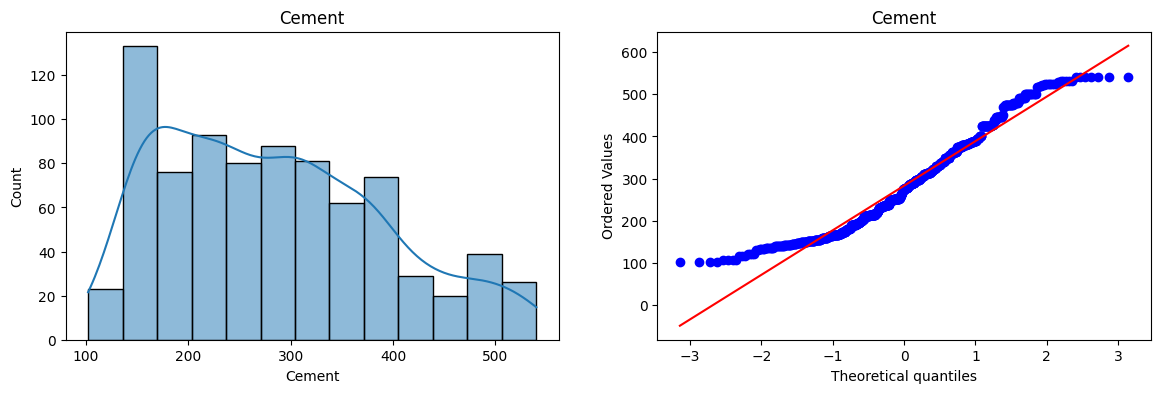

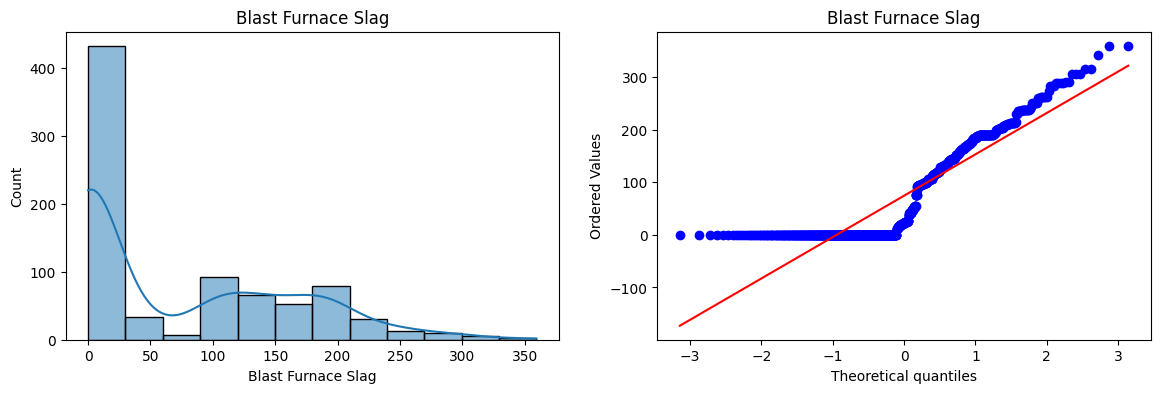

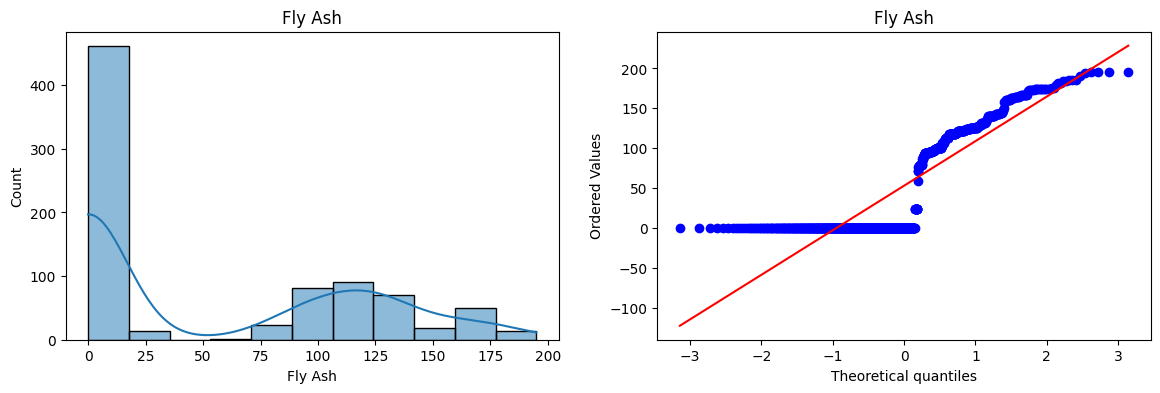

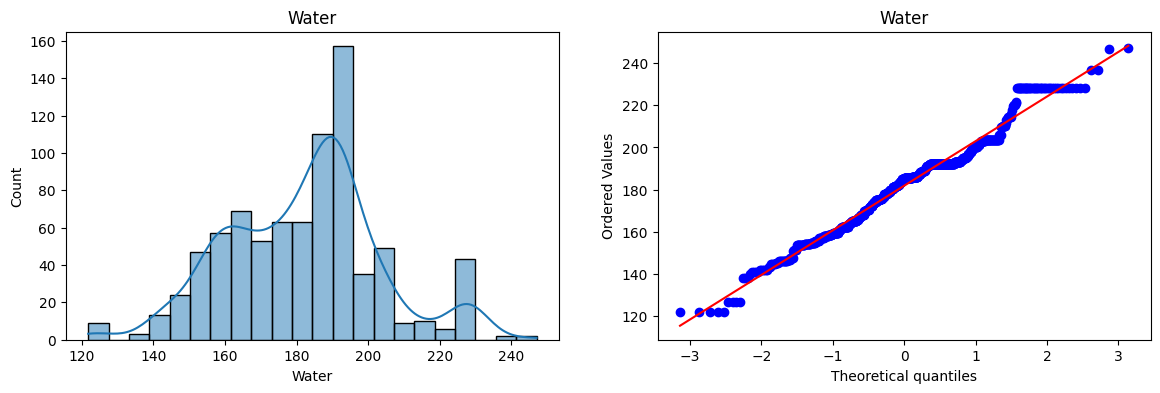

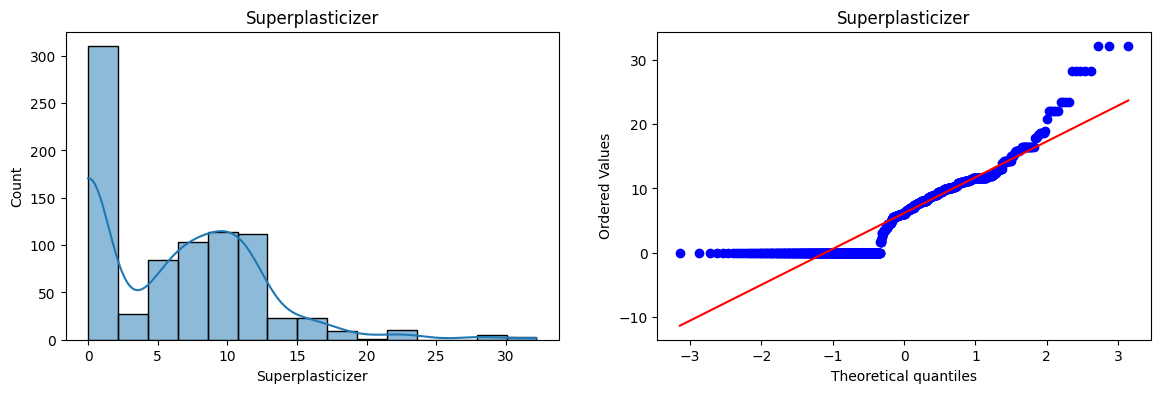

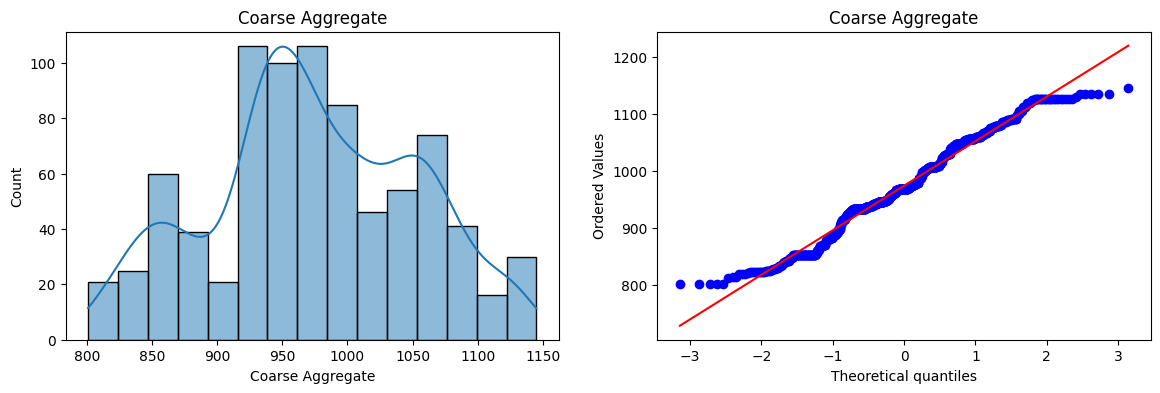

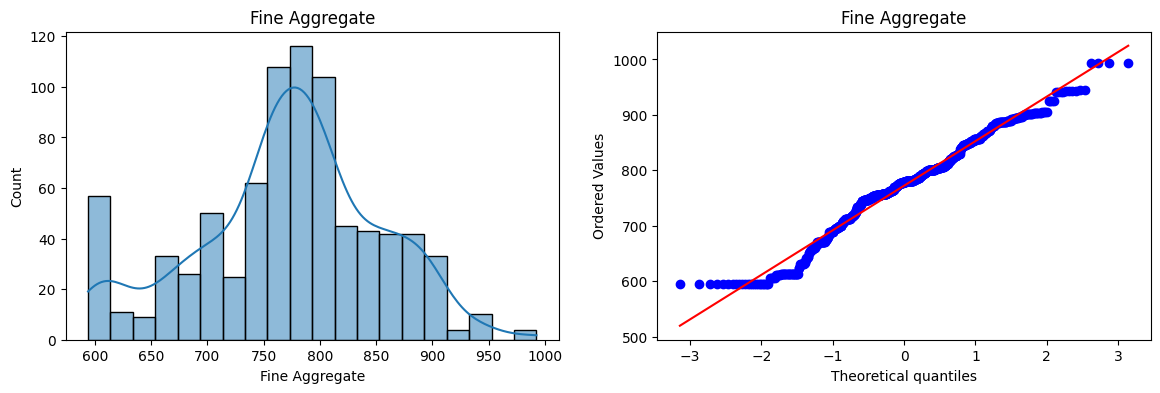

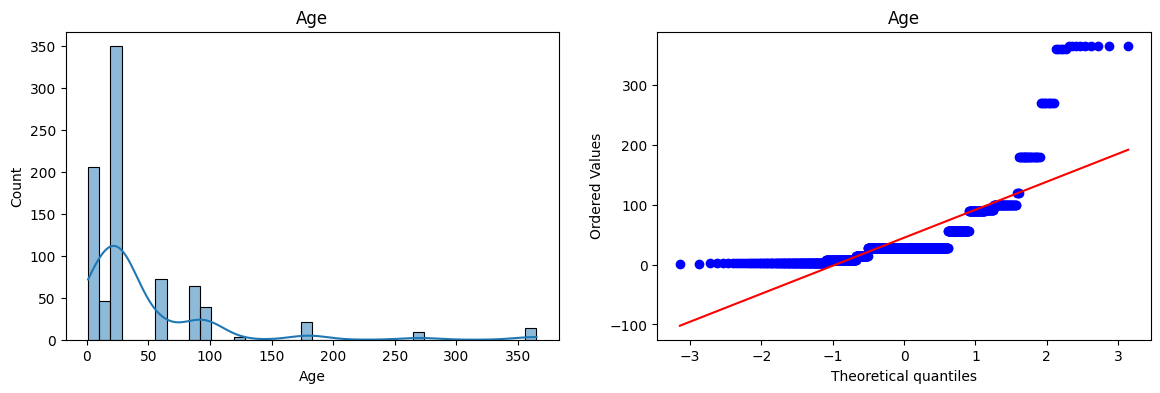

In [172]:
for col in x_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train[col],kde=True)
    plt.title(col)


    plt.subplot(122)
    stats.probplot(x_train[col],dist='norm' , plot=plt)
    plt.title(col)

    plt.show()

In [173]:
PT = PowerTransformer(method ='box-cox')

In [174]:
x_train_trans = PT.fit_transform(x_train+0.000001)
x_test_trans = PT.transform(x_test+0.000001)

In [175]:
pd.DataFrame({'cols': x_train.columns , 'box-cox_lambda':PT.lambdas_})

,cols,box-cox_lambda
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [176]:
LR.fit(x_train_trans,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [177]:
Y_pred_box = LR.predict(x_test_trans)

print('Score',r2_score(y_test,Y_pred_box))

Score 0.8047825008078886


In [178]:
# Cross val always apply on untrained input and output data

x_trans = PT.transform(x+0.000001)
lr = LinearRegression()

cross_val_score(lr,x_trans,y,scoring='r2' , cv=10).mean()


np.float64(0.6440355339196635)

In [179]:
x_train_transformed = pd.DataFrame(x_train_trans,columns=x.columns)

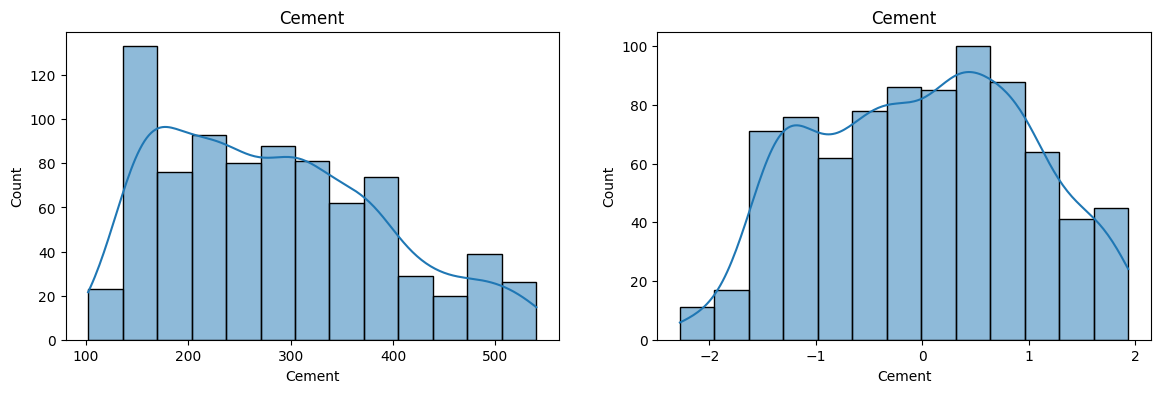

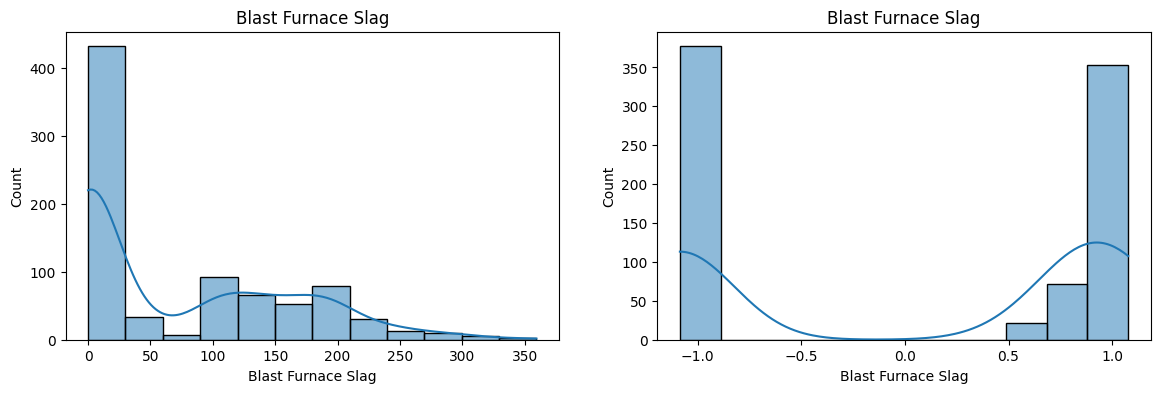

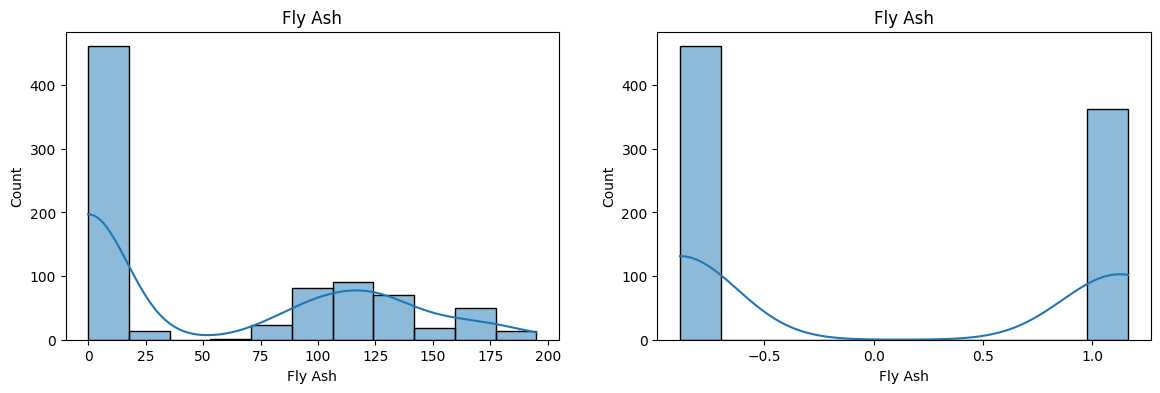

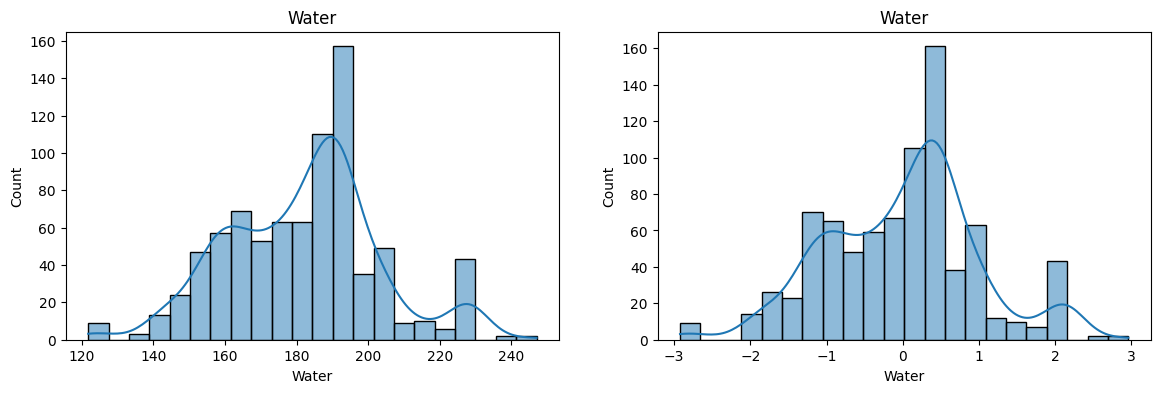

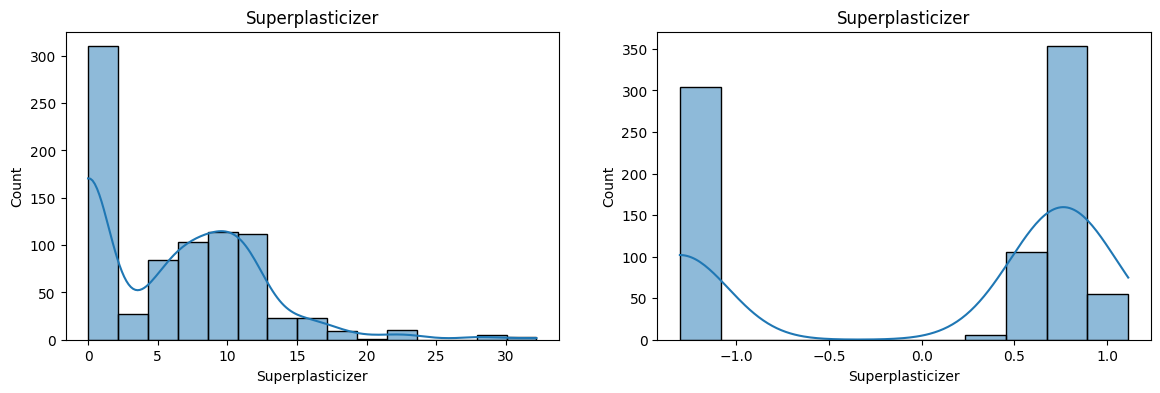

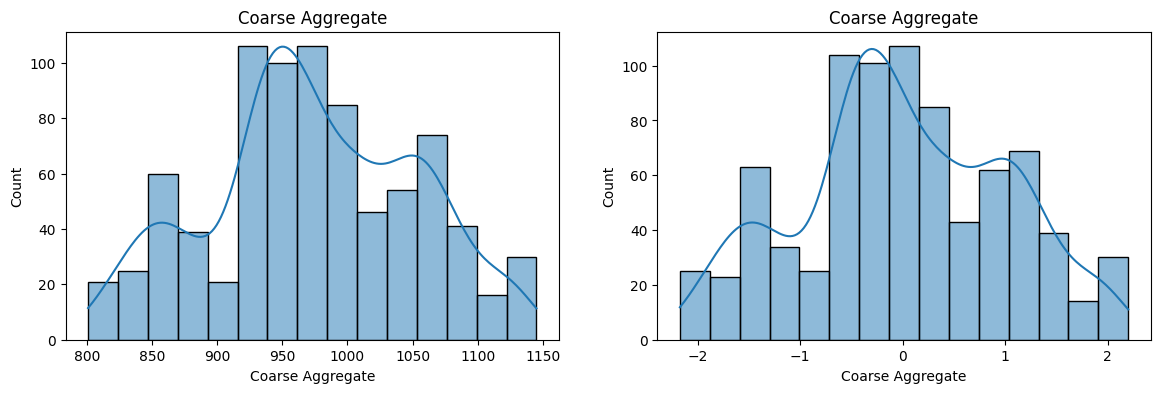

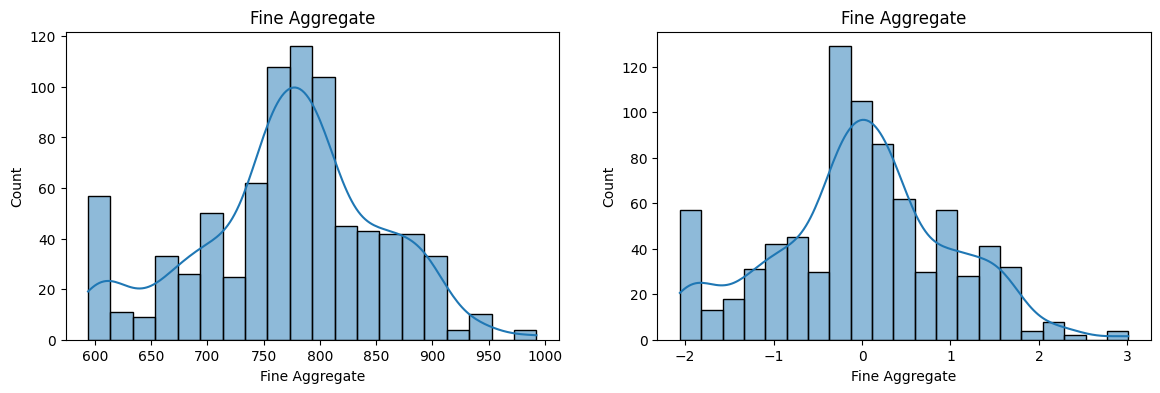

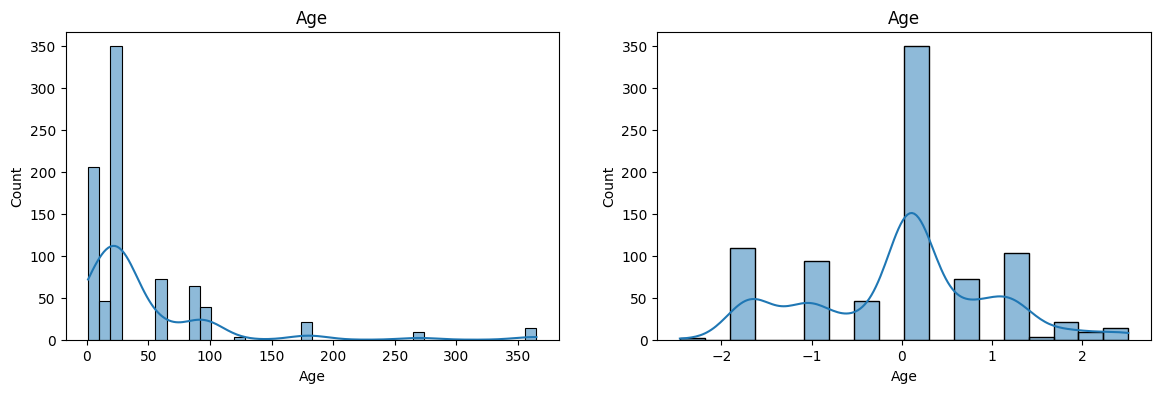

In [180]:
for cols in x_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train[cols],kde=True)
    plt.title(cols)

    plt.subplot(122)
    sns.histplot(x_train_transformed[cols] , kde=True)
    plt.title(cols)

    plt.show()

# Yeo Johonson

In [181]:
pt1 = PowerTransformer() # by default also value is yeo-johonon

x_yeo_trains_trans = pt1.fit_transform(x_train)
x_yeo_test_trans = pt1.transform(x_test)


In [182]:
Lr =  LinearRegression()

Lr.fit(x_yeo_trains_trans,y_train)

y_pred_yeo = Lr.predict(x_yeo_test_trans)

In [183]:
print('Score' , r2_score(y_test,y_pred_yeo))

Score 0.8161906511066099


In [184]:
pd.DataFrame({
    "Cols" : x_train.columns , "yeo-johonson_lmbdas":pt1.lambdas_
})

,Cols,yeo-johonson_lmbdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [185]:
# Cross Val Score

ptc = PowerTransformer()

x_trans = ptc.fit_transform(x)

lrr = LinearRegression()

cross_val_score(lrr,x_trans , y, scoring='r2' , cv=10).mean()

np.float64(0.6586548619389643)

In [188]:
x_trans_yeo_df = pd.DataFrame(x_yeo_trains_trans,columns= x.columns)

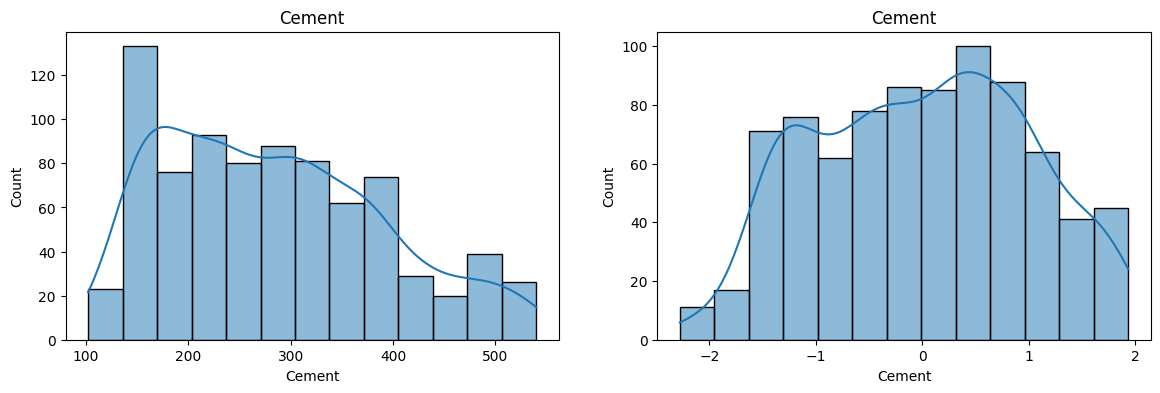

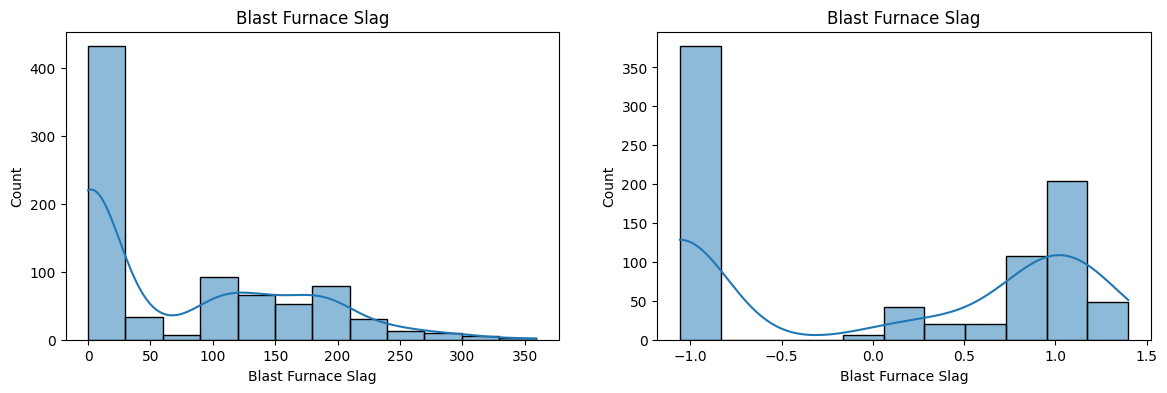

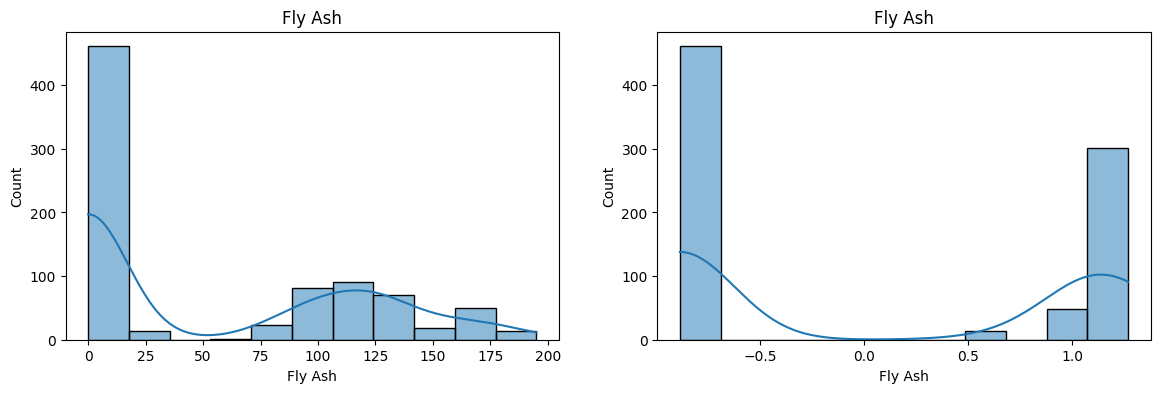

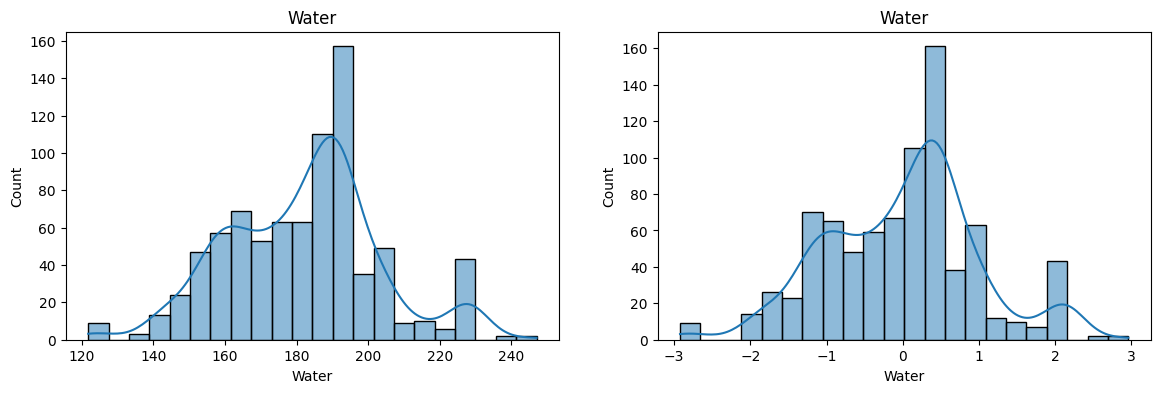

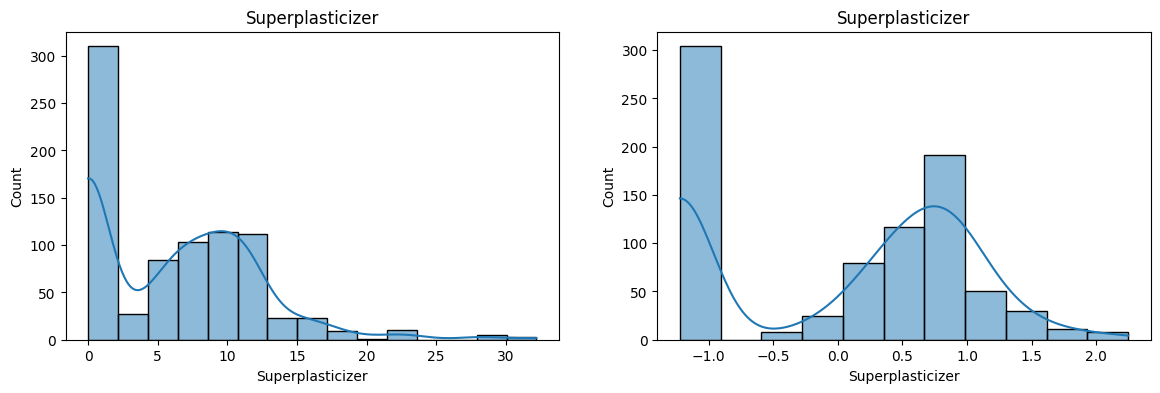

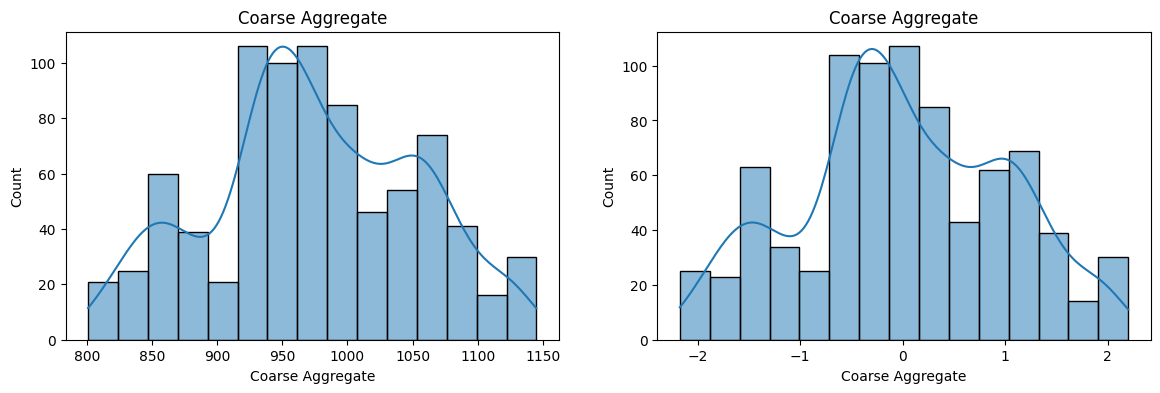

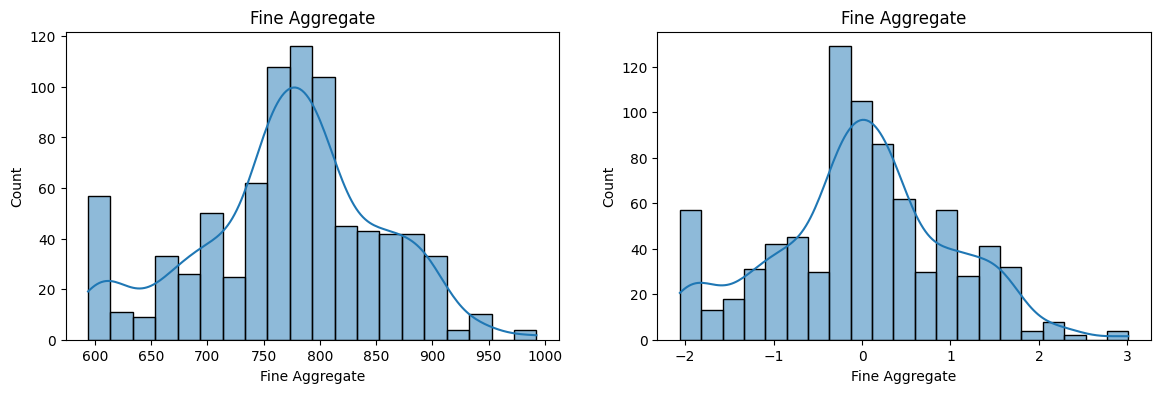

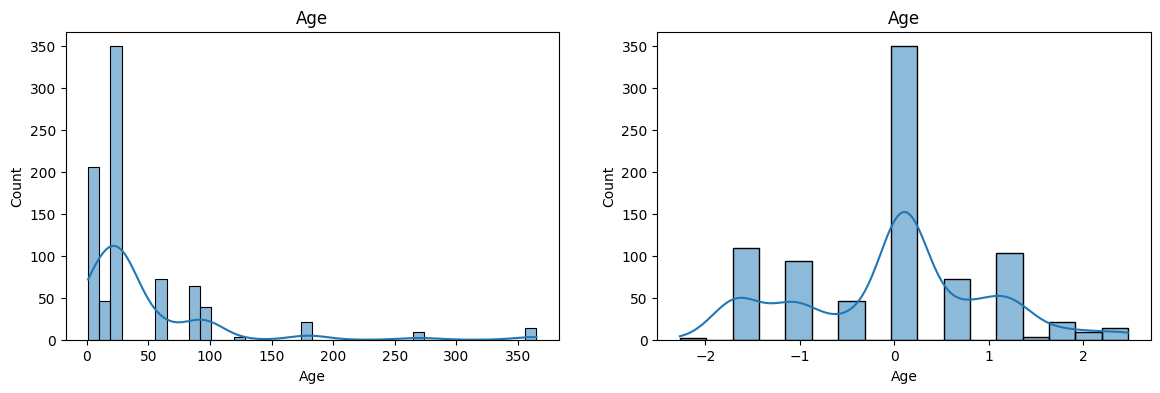

In [190]:
#Graphs Before and After

for columns in x_trans_yeo_df.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train[columns] , kde=True)
    plt.title(columns)

    plt.subplot(122)
    sns.histplot(x_trans_yeo_df[columns],kde=True)
    plt.title(columns)

    plt.show()

In [192]:
Box_yeo_lamb = pd.DataFrame({'cols':x_train.columns , 'box-cox_lambda' : PT.lambdas_ , 'yeo-johonson_lambda':pt1.lambdas_})

In [193]:
Box_yeo_lamb

,cols,box-cox_lambda,yeo-johonson_lambda
0,Cement,0.177025,0.174348
1,Blast Furnace Slag,0.025093,0.015715
2,Fly Ash,-0.038970,-0.161447
3,Water,0.772682,0.771307
4,Superplasticizer,0.098811,0.253935
5,Coarse Aggregate,1.129813,1.130050
6,Fine Aggregate,1.782018,1.783100
7,Age,0.066631,0.019885
